<a href="https://colab.research.google.com/github/AjMing/Pattern-EGCI463/blob/main/Week7-8/Reading_Image_form_a_folder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
!git clone https://github.com/AjMing/Pattern-EGCI463.git
#Make a simple clone the whole, you can select the image partially

Cloning into 'Pattern-EGCI463'...
remote: Enumerating objects: 4781, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 4781 (delta 11), reused 3 (delta 3), pack-reused 4758 (from 3)
Receiving objects: 100% (4781/4781), 32.96 MiB | 12.87 MiB/s, done.
Resolving deltas: 100% (73/73), done.
Updating files: 100% (4639/4639), done.


In [ ]:

import os
import pickle
from skimage.io import imread
from skimage.transform import resize
input_dir = 'Pattern-EGCI463/Image data/'
categories = ['cats','dogs', 'horses']

data = []
labels = []
for category_idx, category in enumerate(categories):
    for file in os.listdir(os.path.join(input_dir, category)):
        img_path = os.path.join(input_dir, category, file)
        img = imread(img_path)
        img = resize(img, (150, 150))
        data.append(img.flatten())
        labels.append(category_idx)


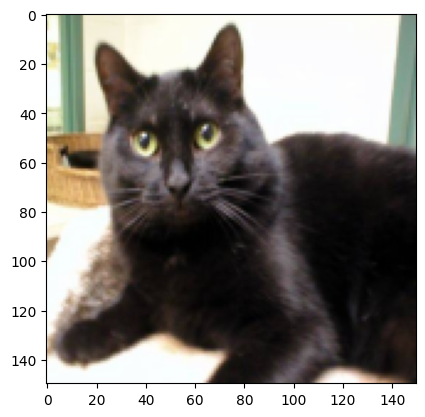

In [ ]:
import matplotlib.pyplot as plt
image_to_plot = data[100].reshape((150, 150, 3))
plt.imshow(image_to_plot)
plt.show()

In [ ]:
os.path.join(input_dir, category, file)

'Pattern-EGCI463/Image data/horses/horse-112.jpg'

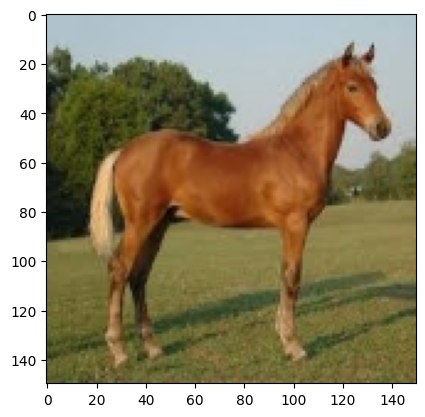

In [ ]:
#show one of the image
import matplotlib.pyplot as plt
plt.imshow(img)

In [ ]:
X=np.array(data)
y=np.array(labels)

In [ ]:
X.shape

(606, 67500)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
nn = MLPClassifier(verbose=1, max_iter=1000)
pca = PCA()

steps = [("pca",pca),("nn", nn)]
pipeline = Pipeline(steps)
param_grid = {"pca__n_components" : [0.95,0.99, 0.999], "nn__learning_rate_init" : [0.1, 0.01, 0.05]}


gs = GridSearchCV(pipeline, param_grid=param_grid,cv=5)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=0, test_size=0.2)

In [ ]:
gs.fit(X_train, y_train)

Iteration 1, loss = 11.05256195
Iteration 2, loss = 8.14899505
Iteration 3, loss = 8.88194820
Iteration 4, loss = 2.85856193
Iteration 5, loss = 3.19778545
Iteration 6, loss = 0.89144535
Iteration 7, loss = 1.78402910
Iteration 8, loss = 0.53804074
Iteration 9, loss = 0.29471331
Iteration 10, loss = 0.24562974
Iteration 11, loss = 0.06348581
Iteration 12, loss = 0.07488002
Iteration 13, loss = 0.03392671
Iteration 14, loss = 0.01416954
Iteration 15, loss = 0.04434801
Iteration 16, loss = 0.03813892
Iteration 17, loss = 0.01376921
Iteration 18, loss = 0.00271931
Iteration 19, loss = 0.00279538
Iteration 20, loss = 0.00187221
Iteration 21, loss = 0.00200331
Iteration 22, loss = 0.00344258
Iteration 23, loss = 0.00225219
Iteration 24, loss = 0.00346379
Iteration 25, loss = 0.00200996
Iteration 26, loss = 0.00200828
Iteration 27, loss = 0.00207036
Iteration 28, loss = 0.00199782
Iteration 29, loss = 0.00198351
Iteration 30, loss = 0.00198420
Iteration 31, loss = 0.00198631
Training loss di

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pca', PCA()),
                                       ('nn',
                                        MLPClassifier(max_iter=1000,
                                                      verbose=1))]),
             param_grid={'nn__learning_rate_init': [0.1, 0.01, 0.05],
                         'pca__n_components': [0.95, 0.99, 0.999]})

In [ ]:
print(gs.best_estimator_)
print(gs.best_params_)
print(gs.best_score_)

Pipeline(steps=[('pca', PCA(n_components=0.95)),
                ('nn',
                 MLPClassifier(learning_rate_init=0.01, max_iter=1000,
                               verbose=1))])
{'nn__learning_rate_init': 0.01, 'pca__n_components': 0.95}
0.5579896907216495


In [ ]:
y_pred = gs.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.56      0.56        39
           1       0.52      0.51      0.52        43
           2       0.78      0.80      0.79        40

    accuracy                           0.62       122
   macro avg       0.62      0.63      0.62       122
weighted avg       0.62      0.62      0.62       122

